# 9-Patch Coordinate Regression Training V2

Train a lightweight CNN to predict 9-patch stretchable regions from UI element images.

**V2 Improvements:**
- Stacked card layers (deck effect)
- Gradient borders
- Inner effects (highlight, shadow, glow)
- Background variations (gradients, textures)
- More element types (pills, wide cards, header cards)

In [ ]:
# Install dependencies (run once)
!pip install -q timm albumentations

In [ ]:
import os
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from dataclasses import dataclass
from typing import Tuple, List, Optional
from pathlib import Path
import json
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [ ]:
# Mount Google Drive for checkpoints
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = Path('/content/drive/MyDrive/9patch_checkpoints_v2')
CHECKPOINT_DIR.mkdir(exist_ok=True)

DATA_CACHE_DIR = Path('/content/9patch_data_v2')
DATA_CACHE_DIR.mkdir(exist_ok=True)

Mounted at /content/drive


In [ ]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Generation V2

Improved generator with complex UI elements.

In [ ]:
@dataclass
class NinePatchCoords:
    """Normalized 9-patch coordinates in [0,1] range."""
    stretch_left: float
    stretch_right: float
    stretch_top: float
    stretch_bottom: float

    def to_array(self) -> np.ndarray:
        return np.array([self.stretch_left, self.stretch_right,
                         self.stretch_top, self.stretch_bottom], dtype=np.float32)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> 'NinePatchCoords':
        return cls(*arr.tolist())

    def to_pixels(self, width: int, height: int) -> 'NinePatchCoords':
        return NinePatchCoords(
            stretch_left=int(self.stretch_left * width),
            stretch_right=int(self.stretch_right * width),
            stretch_top=int(self.stretch_top * height),
            stretch_bottom=int(self.stretch_bottom * height),
        )

    def flip_horizontal(self) -> 'NinePatchCoords':
        return NinePatchCoords(
            stretch_left=1.0 - self.stretch_right,
            stretch_right=1.0 - self.stretch_left,
            stretch_top=self.stretch_top,
            stretch_bottom=self.stretch_bottom,
        )

    def flip_vertical(self) -> 'NinePatchCoords':
        return NinePatchCoords(
            stretch_left=self.stretch_left,
            stretch_right=self.stretch_right,
            stretch_top=1.0 - self.stretch_bottom,
            stretch_bottom=1.0 - self.stretch_top,
        )

In [ ]:
class NinePatchGeneratorV2:
    """
    Generates synthetic UI elements with 9-patch ground truth.

    V2 Features:
    - Stacked card layers for depth effects
    - Gradient borders (linear, multi-stop)
    - Inner effects (highlight, shadow, glow)
    - Background variations (gradients, textures)
    - More element types (pills, wide cards, header cards)
    """

    def __init__(self, output_size: Tuple[int, int] = (224, 224)):
        self.output_size = output_size

    def generate_sample(self, curriculum_stage: int = 1) -> Tuple[np.ndarray, NinePatchCoords]:
        """Generate a synthetic UI element with ground truth coordinates."""
        element_type = self._select_element_type(curriculum_stage)

        if element_type == 'pill':
            return self._generate_pill(curriculum_stage)
        elif element_type == 'wide_card':
            return self._generate_wide_card(curriculum_stage)
        elif element_type == 'header_card':
            return self._generate_header_card(curriculum_stage)
        else:
            return self._generate_standard_card(curriculum_stage)

    def _select_element_type(self, stage: int) -> str:
        if stage <= 2:
            return 'standard'
        types = ['standard', 'standard', 'standard']
        if stage >= 3:
            types.extend(['pill', 'wide_card'])
        if stage >= 4:
            types.extend(['header_card', 'pill', 'wide_card'])
        return random.choice(types)

    def _generate_standard_card(self, stage: int) -> Tuple[np.ndarray, NinePatchCoords]:
        elem_width = random.randint(80, 180)
        elem_height = random.randint(40, 120)
        corner_radius = self._get_corner_radius(stage)

        num_stack_layers = 0
        stack_offset = 0
        if stage >= 3 and random.random() > 0.5:
            num_stack_layers = random.randint(1, 2 if stage == 3 else 3)
            stack_offset = random.randint(3, 6)

        shadow_pad = 30 if stage >= 2 else 20
        stack_pad = num_stack_layers * stack_offset
        pad_left = shadow_pad
        pad_top = shadow_pad
        pad_right = shadow_pad + stack_pad
        pad_bottom = shadow_pad + stack_pad

        canvas_w = elem_width + pad_left + pad_right
        canvas_h = elem_height + pad_top + pad_bottom

        img = self._create_background(canvas_w, canvas_h, stage)
        main_bbox = (pad_left, pad_top, pad_left + elem_width, pad_top + elem_height)

        if stage >= 2:
            img = self._add_shadow(img, main_bbox, corner_radius, stage)

        if num_stack_layers > 0:
            img = self._add_stacked_layers(
                img, main_bbox, corner_radius, num_stack_layers, stack_offset, stage
            )

        img = self._draw_card(img, main_bbox, corner_radius, stage)

        if stage >= 3:
            img = self._add_inner_effects(img, main_bbox, corner_radius, stage)

        if stage >= 2:
            img = self._add_noise(img, stage)

        # Option B: coords based on main card only
        coords = self._compute_coords(main_bbox, corner_radius, canvas_w, canvas_h)

        img_rgb = img.convert('RGB').resize(self.output_size, Image.LANCZOS)
        return np.array(img_rgb), coords

    def _generate_pill(self, stage: int) -> Tuple[np.ndarray, NinePatchCoords]:
        elem_width = random.randint(50, 100)
        elem_height = random.randint(24, 36)
        corner_radius = elem_height // 2

        pad = 25
        canvas_w = elem_width + pad * 2
        canvas_h = elem_height + pad * 2

        img = self._create_background(canvas_w, canvas_h, stage)
        bbox = (pad, pad, pad + elem_width, pad + elem_height)

        if stage >= 2:
            img = self._add_shadow(img, bbox, corner_radius, stage)

        img = self._draw_card(img, bbox, corner_radius, stage)

        if stage >= 3:
            img = self._add_inner_effects(img, bbox, corner_radius, stage)

        if stage >= 2:
            img = self._add_noise(img, stage)

        coords = self._compute_coords(bbox, corner_radius, canvas_w, canvas_h)
        img_rgb = img.convert('RGB').resize(self.output_size, Image.LANCZOS)
        return np.array(img_rgb), coords

    def _generate_wide_card(self, stage: int) -> Tuple[np.ndarray, NinePatchCoords]:
        elem_width = random.randint(180, 220)
        elem_height = random.randint(30, 50)
        corner_radius = self._get_corner_radius(stage)
        corner_radius = min(corner_radius, elem_height // 2)

        pad = 25
        canvas_w = elem_width + pad * 2
        canvas_h = elem_height + pad * 2

        img = self._create_background(canvas_w, canvas_h, stage)
        bbox = (pad, pad, pad + elem_width, pad + elem_height)

        if stage >= 2:
            img = self._add_shadow(img, bbox, corner_radius, stage)

        img = self._draw_card(img, bbox, corner_radius, stage)

        if stage >= 3:
            img = self._add_inner_effects(img, bbox, corner_radius, stage)

        if stage >= 2:
            img = self._add_noise(img, stage)

        coords = self._compute_coords(bbox, corner_radius, canvas_w, canvas_h)
        img_rgb = img.convert('RGB').resize(self.output_size, Image.LANCZOS)
        return np.array(img_rgb), coords

    def _generate_header_card(self, stage: int) -> Tuple[np.ndarray, NinePatchCoords]:
        elem_width = random.randint(100, 180)
        elem_height = random.randint(80, 120)
        header_height = random.randint(20, 35)
        corner_radius = self._get_corner_radius(stage)

        pad = 30
        canvas_w = elem_width + pad * 2
        canvas_h = elem_height + pad * 2

        img = self._create_background(canvas_w, canvas_h, stage)
        bbox = (pad, pad, pad + elem_width, pad + elem_height)

        if stage >= 2:
            img = self._add_shadow(img, bbox, corner_radius, stage)

        draw = ImageDraw.Draw(img)
        body_color = self._random_color(alpha=255)
        draw.rounded_rectangle(bbox, radius=corner_radius, fill=body_color)

        header_color = self._random_color(alpha=255)
        header_img = Image.new('RGBA', img.size, (0, 0, 0, 0))
        header_draw = ImageDraw.Draw(header_img)
        header_draw.rounded_rectangle(bbox, radius=corner_radius, fill=header_color)
        body_rect = (bbox[0], bbox[1] + header_height, bbox[2], bbox[3])
        header_draw.rectangle(body_rect, fill=body_color)
        img = Image.alpha_composite(img, header_img)

        if random.random() > 0.3:
            draw = ImageDraw.Draw(img)
            border_color = self._random_color(alpha=255)
            draw.rounded_rectangle(bbox, radius=corner_radius, outline=border_color, width=2)

        if stage >= 3:
            img = self._add_inner_effects(img, bbox, corner_radius, stage)

        if stage >= 2:
            img = self._add_noise(img, stage)

        coords = self._compute_coords(bbox, corner_radius, canvas_w, canvas_h)
        img_rgb = img.convert('RGB').resize(self.output_size, Image.LANCZOS)
        return np.array(img_rgb), coords

    def _add_stacked_layers(self, img: Image.Image, main_bbox: Tuple[int, int, int, int],
                            radius: int, num_layers: int, offset: int,
                            stage: int) -> Image.Image:
        x0, y0, x1, y1 = main_bbox

        for i in range(num_layers, 0, -1):
            layer_offset = offset * i
            layer_bbox = (
                x0 + layer_offset,
                y0 + layer_offset,
                x1 + layer_offset,
                y1 + layer_offset
            )

            darkness = 0.85 - (i * 0.1)
            base_color = self._random_color(alpha=255)
            layer_color = tuple(int(c * darkness) for c in base_color[:3]) + (255,)

            img = self._add_shadow(img, layer_bbox, radius, stage, alpha_mult=0.5)

            draw = ImageDraw.Draw(img)
            draw.rounded_rectangle(layer_bbox, radius=radius, fill=layer_color)

            if random.random() > 0.5:
                border_color = tuple(int(c * 0.7) for c in layer_color[:3]) + (255,)
                draw.rounded_rectangle(layer_bbox, radius=radius,
                                       outline=border_color, width=1)

        return img

    def _draw_card(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                   radius: int, stage: int) -> Image.Image:
        draw = ImageDraw.Draw(img)
        fill_color = self._random_color(alpha=255)
        draw.rounded_rectangle(bbox, radius=radius, fill=fill_color)

        if random.random() > 0.3:
            if stage >= 3 and random.random() > 0.5:
                img = self._draw_gradient_border(img, bbox, radius, stage)
            else:
                border_color = self._random_color(alpha=255)
                border_width = random.randint(1, 3)
                draw.rounded_rectangle(bbox, radius=radius,
                                       outline=border_color, width=border_width)

        return img

    def _draw_gradient_border(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                              radius: int, stage: int) -> Image.Image:
        x0, y0, x1, y1 = bbox
        border_width = random.randint(2, 4)

        num_stops = random.randint(2, 4)
        colors = [self._random_vibrant_color() for _ in range(num_stops)]
        direction = random.choice(['horizontal', 'vertical', 'diagonal'])

        border_mask = Image.new('L', img.size, 0)
        mask_draw = ImageDraw.Draw(border_mask)
        mask_draw.rounded_rectangle(bbox, radius=radius, fill=255)
        inner_bbox = (x0 + border_width, y0 + border_width,
                      x1 - border_width, y1 - border_width)
        inner_radius = max(0, radius - border_width)
        mask_draw.rounded_rectangle(inner_bbox, radius=inner_radius, fill=0)

        gradient = self._create_gradient(img.size, colors, direction)
        img.paste(gradient, mask=border_mask)

        return img

    def _create_gradient(self, size: Tuple[int, int], colors: List[Tuple[int, int, int]],
                         direction: str) -> Image.Image:
        w, h = size
        gradient = Image.new('RGBA', size)

        if direction == 'horizontal':
            for x in range(w):
                t = x / max(1, w - 1)
                color = self._interpolate_colors(colors, t)
                ImageDraw.Draw(gradient).line([(x, 0), (x, h)], fill=color)
        elif direction == 'vertical':
            for y in range(h):
                t = y / max(1, h - 1)
                color = self._interpolate_colors(colors, t)
                ImageDraw.Draw(gradient).line([(0, y), (w, y)], fill=color)
        else:
            for x in range(w):
                for y in range(h):
                    t = (x + y) / max(1, w + h - 2)
                    color = self._interpolate_colors(colors, t)
                    gradient.putpixel((x, y), color)

        return gradient

    def _interpolate_colors(self, colors: List[Tuple[int, int, int]], t: float) -> Tuple[int, int, int, int]:
        n = len(colors)
        if n == 0:
            return (128, 128, 128, 255)  # Default gray for empty list
        if n == 1:
            return colors[0] + (255,)

        t = max(0, min(1, t))
        segment_size = 1.0 / (n - 1)
        segment = min(int(t / segment_size), n - 2)
        local_t = (t - segment * segment_size) / segment_size

        c1 = colors[segment]
        c2 = colors[segment + 1]

        r = int(c1[0] + (c2[0] - c1[0]) * local_t)
        g = int(c1[1] + (c2[1] - c1[1]) * local_t)
        b = int(c1[2] + (c2[2] - c1[2]) * local_t)

        return (r, g, b, 255)

    def _add_inner_effects(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                           radius: int, stage: int) -> Image.Image:
        effects = []
        if random.random() > 0.5:
            effects.append('highlight')
        if random.random() > 0.6:
            effects.append('inner_shadow')
        if random.random() > 0.7:
            effects.append('inner_glow')

        for effect in effects:
            if effect == 'highlight':
                img = self._add_top_highlight(img, bbox, radius)
            elif effect == 'inner_shadow':
                img = self._add_inner_shadow(img, bbox, radius)
            elif effect == 'inner_glow':
                img = self._add_inner_glow(img, bbox, radius)

        return img

    def _add_top_highlight(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                           radius: int) -> Image.Image:
        x0, y0, x1, y1 = bbox
        highlight_height = min(20, (y1 - y0) // 3)

        highlight = Image.new('RGBA', img.size, (0, 0, 0, 0))

        for y in range(highlight_height):
            alpha = int(40 * (1 - y / highlight_height))
            for x in range(x0, x1):
                if self._point_in_rounded_rect(x, y + y0, bbox, radius):
                    highlight.putpixel((x, y + y0), (255, 255, 255, alpha))

        return Image.alpha_composite(img, highlight)

    def _add_inner_shadow(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                          radius: int) -> Image.Image:
        x0, y0, x1, y1 = bbox
        shadow_size = random.randint(3, 8)

        shadow = Image.new('RGBA', img.size, (0, 0, 0, 0))

        for y in range(y0, y1):
            for x in range(x0, x1):
                if not self._point_in_rounded_rect(x, y, bbox, radius):
                    continue

                dist_left = x - x0
                dist_right = x1 - x
                dist_top = y - y0
                dist_bottom = y1 - y
                min_dist = min(dist_left, dist_right, dist_top, dist_bottom)

                if min_dist < shadow_size:
                    alpha = int(30 * (1 - min_dist / shadow_size))
                    shadow.putpixel((x, y), (0, 0, 0, alpha))

        return Image.alpha_composite(img, shadow)

    def _add_inner_glow(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                        radius: int) -> Image.Image:
        x0, y0, x1, y1 = bbox
        glow_size = random.randint(5, 12)
        glow_color = self._random_vibrant_color()

        glow = Image.new('RGBA', img.size, (0, 0, 0, 0))

        for y in range(y0, y1):
            for x in range(x0, x1):
                if not self._point_in_rounded_rect(x, y, bbox, radius):
                    continue

                dist_left = x - x0
                dist_right = x1 - x
                dist_top = y - y0
                dist_bottom = y1 - y
                min_dist = min(dist_left, dist_right, dist_top, dist_bottom)

                if min_dist < glow_size:
                    alpha = int(25 * (1 - min_dist / glow_size))
                    glow.putpixel((x, y), glow_color + (alpha,))

        return Image.alpha_composite(img, glow)

    def _point_in_rounded_rect(self, x: int, y: int, bbox: Tuple[int, int, int, int],
                                radius: int) -> bool:
        x0, y0, x1, y1 = bbox

        if not (x0 <= x < x1 and y0 <= y < y1):
            return False

        if radius <= 0:
            return True

        corners = [
            (x0 + radius, y0 + radius),
            (x1 - radius, y0 + radius),
            (x0 + radius, y1 - radius),
            (x1 - radius, y1 - radius),
        ]

        if x < x0 + radius and y < y0 + radius:
            cx, cy = corners[0]
            if (x - cx) ** 2 + (y - cy) ** 2 > radius ** 2:
                return False

        if x >= x1 - radius and y < y0 + radius:
            cx, cy = corners[1]
            if (x - cx) ** 2 + (y - cy) ** 2 > radius ** 2:
                return False

        if x < x0 + radius and y >= y1 - radius:
            cx, cy = corners[2]
            if (x - cx) ** 2 + (y - cy) ** 2 > radius ** 2:
                return False

        if x >= x1 - radius and y >= y1 - radius:
            cx, cy = corners[3]
            if (x - cx) ** 2 + (y - cy) ** 2 > radius ** 2:
                return False

        return True

    def _create_background(self, width: int, height: int, stage: int) -> Image.Image:
        if stage <= 2:
            v = random.randint(240, 255)
            return Image.new('RGBA', (width, height), (v, v, v, 255))

        bg_type = random.choice(['solid', 'solid', 'gradient', 'textured'])

        if bg_type == 'solid':
            color = self._random_color(alpha=255)
            return Image.new('RGBA', (width, height), color)

        elif bg_type == 'gradient':
            colors = [self._random_color()[:3] for _ in range(2)]
            direction = random.choice(['horizontal', 'vertical'])
            img = self._create_gradient((width, height), colors, direction)
            return img.convert('RGBA')

        else:
            base_color = self._random_color(alpha=255)
            img = Image.new('RGBA', (width, height), base_color)
            arr = np.array(img).astype(np.float32)
            noise = np.random.normal(0, 5, arr.shape)
            arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
            return Image.fromarray(arr, mode='RGBA')

    def _compute_coords(self, bbox: Tuple[int, int, int, int], radius: int,
                        img_w: int, img_h: int) -> NinePatchCoords:
        x0, y0, x1, y1 = bbox
        elem_w = x1 - x0
        elem_h = y1 - y0

        min_stretch = 4
        max_margin_x = max(1, (elem_w - min_stretch) // 2)
        max_margin_y = max(1, (elem_h - min_stretch) // 2)

        margin_x = min(max(1, radius), max_margin_x)
        margin_y = min(max(1, radius), max_margin_y)

        return NinePatchCoords(
            stretch_left=(x0 + margin_x) / img_w,
            stretch_right=(x1 - margin_x) / img_w,
            stretch_top=(y0 + margin_y) / img_h,
            stretch_bottom=(y1 - margin_y) / img_h,
        )

    def _add_shadow(self, img: Image.Image, bbox: Tuple[int, int, int, int],
                    radius: int, stage: int, alpha_mult: float = 1.0) -> Image.Image:
        offset_x = random.randint(2, 6)
        offset_y = random.randint(2, 8)
        blur_radius = random.randint(6, 12) if stage >= 3 else 8
        shadow_alpha = int(random.randint(40, 80) * alpha_mult)

        shadow = Image.new('RGBA', img.size, (0, 0, 0, 0))
        shadow_draw = ImageDraw.Draw(shadow)

        shadow_bbox = (bbox[0] + offset_x, bbox[1] + offset_y,
                       bbox[2] + offset_x, bbox[3] + offset_y)
        shadow_draw.rounded_rectangle(shadow_bbox, radius=radius,
                                      fill=(0, 0, 0, shadow_alpha))

        shadow = shadow.filter(ImageFilter.GaussianBlur(blur_radius))
        shadow.paste(img, (0, 0), img)
        return shadow

    def _add_noise(self, img: Image.Image, stage: int) -> Image.Image:
        arr = np.array(img).astype(np.float32)
        noise_std = min(8, (stage - 1) * 3)
        noise = np.random.normal(0, noise_std, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr, mode='RGBA')

    def _get_corner_radius(self, stage: int) -> int:
        if stage == 1:
            return random.choice([0, 4, 8, 12])
        elif stage == 2:
            return random.randint(0, 20)
        else:
            return random.randint(0, 35)

    def _random_color(self, alpha: int = 255) -> Tuple[int, int, int, int]:
        return (random.randint(40, 240), random.randint(40, 240),
                random.randint(40, 240), alpha)

    def _random_vibrant_color(self) -> Tuple[int, int, int]:
        hue = random.random()

        if hue < 1/6:
            r, g, b = 255, int(255 * hue * 6), 0
        elif hue < 2/6:
            r, g, b = int(255 * (2 - hue * 6)), 255, 0
        elif hue < 3/6:
            r, g, b = 0, 255, int(255 * (hue * 6 - 2))
        elif hue < 4/6:
            r, g, b = 0, int(255 * (4 - hue * 6)), 255
        elif hue < 5/6:
            r, g, b = int(255 * (hue * 6 - 4)), 0, 255
        else:
            r, g, b = 255, 0, int(255 * (6 - hue * 6))

        r = max(100, min(255, r + random.randint(-30, 30)))
        g = max(100, min(255, g + random.randint(-30, 30)))
        b = max(100, min(255, b + random.randint(-30, 30)))

        return (r, g, b)

## Dataset with Caching and Augmentation

In [ ]:
def generate_and_cache_dataset(generator: NinePatchGeneratorV2,
                                n_samples: int,
                                stage: int,
                                cache_dir: Path,
                                split: str = 'train') -> Path:
    """Generate samples and cache to disk."""
    split_dir = cache_dir / f'stage{stage}' / split
    split_dir.mkdir(parents=True, exist_ok=True)

    meta_file = split_dir / 'metadata.json'
    if meta_file.exists():
        with open(meta_file) as f:
            meta = json.load(f)
        if meta.get('n_samples') == n_samples:
            print(f"Using cached {split} data for stage {stage} ({n_samples} samples)")
            return split_dir

    print(f"Generating {n_samples} {split} samples for stage {stage}...")

    coords_list = []
    for i in tqdm(range(n_samples)):
        img_arr, coords = generator.generate_sample(curriculum_stage=stage)
        img = Image.fromarray(img_arr)
        img.save(split_dir / f'{i:05d}.png')
        coords_list.append(coords.to_array().tolist())

    with open(meta_file, 'w') as f:
        json.dump({
            'n_samples': n_samples,
            'stage': stage,
            'coords': coords_list
        }, f)

    print(f"Cached to {split_dir}")
    return split_dir

In [ ]:
class NinePatchDataset(Dataset):
    """Dataset with coordinate-safe augmentations."""

    def __init__(self, data_dir: Path, augment: bool = True):
        self.data_dir = Path(data_dir)

        with open(self.data_dir / 'metadata.json') as f:
            meta = json.load(f)

        self.coords = [np.array(c, dtype=np.float32) for c in meta['coords']]
        self.n_samples = meta['n_samples']
        self.augment = augment

        self.color_aug = A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
            A.GaussNoise(var_limit=(5, 30), p=0.3),
        ])

        self.normalize = A.Compose([
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img_path = self.data_dir / f'{idx:05d}.png'
        img = np.array(Image.open(img_path).convert('RGB'))

        coords = self.coords[idx].copy()

        if self.augment:
            img = self.color_aug(image=img)['image']

            if random.random() > 0.5:
                img = np.fliplr(img).copy()
                coords[0], coords[1] = 1.0 - coords[1], 1.0 - coords[0]

            if random.random() > 0.5:
                img = np.flipud(img).copy()
                coords[2], coords[3] = 1.0 - coords[3], 1.0 - coords[2]

        img = self.normalize(image=img)['image']

        return img, torch.tensor(coords, dtype=torch.float32)

## Model Architecture

In [ ]:
class NinePatchRegressor(nn.Module):
    """Predicts 4 normalized 9-patch coordinates from an image."""

    def __init__(self, backbone: str = 'efficientnet_b0', pretrained: bool = True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        feat_dim = self.backbone.num_features
        print(f"Backbone: {backbone}, feature dim: {feat_dim}")

        self.regressor = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.regressor(features)

In [ ]:
# Test model
model = NinePatchRegressor('efficientnet_b0', pretrained=True)
dummy_input = torch.randn(2, 3, 224, 224)
output = model(dummy_input)
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min().item():.3f}, {output.max().item():.3f}]")

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,} ({n_params/1e6:.1f}M)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone: efficientnet_b0, feature dim: 1280
Output shape: torch.Size([2, 4])
Output range: [0.473, 0.543]
Total parameters: 4,352,192 (4.4M)


## Validation Metrics

In [ ]:
def compute_region_iou(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    pred_left, pred_right, pred_top, pred_bottom = pred.unbind(dim=1)
    tgt_left, tgt_right, tgt_top, tgt_bottom = target.unbind(dim=1)

    inter_left = torch.max(pred_left, tgt_left)
    inter_right = torch.min(pred_right, tgt_right)
    inter_top = torch.max(pred_top, tgt_top)
    inter_bottom = torch.min(pred_bottom, tgt_bottom)

    inter_w = (inter_right - inter_left).clamp(min=0)
    inter_h = (inter_bottom - inter_top).clamp(min=0)
    inter_area = inter_w * inter_h

    pred_area = (pred_right - pred_left) * (pred_bottom - pred_top)
    tgt_area = (tgt_right - tgt_left) * (tgt_bottom - tgt_top)
    union_area = pred_area + tgt_area - inter_area

    iou = inter_area / (union_area + 1e-7)
    return iou


def compute_coord_error(pred: torch.Tensor, target: torch.Tensor, img_size: int = 224) -> dict:
    pred_px = pred * img_size
    tgt_px = target * img_size

    abs_err = (pred_px - tgt_px).abs()

    return {
        'mae_left': abs_err[:, 0].mean().item(),
        'mae_right': abs_err[:, 1].mean().item(),
        'mae_top': abs_err[:, 2].mean().item(),
        'mae_bottom': abs_err[:, 3].mean().item(),
        'mae_overall': abs_err.mean().item(),
    }

## Training Loop

In [ ]:
class Trainer:
    def __init__(self, model, device, checkpoint_dir):
        self.model = model.to(device)
        self.device = device
        self.checkpoint_dir = Path(checkpoint_dir)

        self.criterion = nn.SmoothL1Loss()
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
        self.scaler = GradScaler()

        self.best_iou = 0.0
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_mae': []}

    def train_epoch(self, train_loader, scheduler=None):
        self.model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc='Training')
        for images, targets in pbar:
            images = images.to(self.device)
            targets = targets.to(self.device)

            self.optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            if scheduler:
                scheduler.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        return total_loss / len(train_loader)

    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        all_ious = []
        all_errors = []

        for images, targets in tqdm(val_loader, desc='Validating'):
            images = images.to(self.device)
            targets = targets.to(self.device)

            with autocast(device_type='cuda'):
                outputs = self.model(images)
                loss = self.criterion(outputs, targets)

            total_loss += loss.item()

            ious = compute_region_iou(outputs, targets)
            all_ious.append(ious.cpu())

            errors = compute_coord_error(outputs.cpu(), targets.cpu())
            all_errors.append(errors)

        avg_loss = total_loss / len(val_loader)
        avg_iou = torch.cat(all_ious).mean().item()
        avg_mae = np.mean([e['mae_overall'] for e in all_errors])

        return {
            'loss': avg_loss,
            'iou': avg_iou,
            'mae_px': avg_mae,
        }

    def save_checkpoint(self, epoch, val_metrics, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'val_metrics': val_metrics,
            'history': self.history,
        }

        path = self.checkpoint_dir / f'checkpoint_epoch{epoch}.pth'
        torch.save(checkpoint, path)

        if is_best:
            best_path = self.checkpoint_dir / 'best_model.pth'
            torch.save(checkpoint, best_path)
            print(f"  Saved new best model (IoU: {val_metrics['iou']:.4f})")

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.history = checkpoint.get('history', self.history)
        self.best_iou = checkpoint.get('val_metrics', {}).get('iou', 0.0)
        return checkpoint['epoch']

In [ ]:
def train_with_curriculum(trainer, generator, data_cache_dir,
                          stages_config, batch_size=32):
    global_epoch = 0

    for stage_cfg in stages_config:
        stage = stage_cfg['stage']
        n_epochs = stage_cfg['epochs']

        print(f"\n{'='*60}")
        print(f"CURRICULUM STAGE {stage} - {n_epochs} epochs")
        print(f"{'='*60}")

        train_dir = generate_and_cache_dataset(
            generator, stage_cfg['train_samples'], stage, data_cache_dir, 'train'
        )
        val_dir = generate_and_cache_dataset(
            generator, stage_cfg['val_samples'], stage, data_cache_dir, 'val'
        )

        train_dataset = NinePatchDataset(train_dir, augment=True)
        val_dataset = NinePatchDataset(val_dir, augment=False)

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            num_workers=2, pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, num_workers=2
        )

        for epoch in range(n_epochs):
            global_epoch += 1
            print(f"\nEpoch {global_epoch} (Stage {stage}, epoch {epoch+1}/{n_epochs})")

            scheduler = OneCycleLR(
                trainer.optimizer,
                max_lr=3e-4,
                epochs=1,
                steps_per_epoch=len(train_loader)
            )

            train_loss = trainer.train_epoch(train_loader, scheduler)
            val_metrics = trainer.validate(val_loader)

            trainer.history['train_loss'].append(train_loss)
            trainer.history['val_loss'].append(val_metrics['loss'])
            trainer.history['val_iou'].append(val_metrics['iou'])
            trainer.history['val_mae'].append(val_metrics['mae_px'])

            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_metrics['loss']:.4f}, IoU: {val_metrics['iou']:.4f}, MAE: {val_metrics['mae_px']:.1f}px")

            is_best = val_metrics['iou'] > trainer.best_iou
            if is_best:
                trainer.best_iou = val_metrics['iou']

            if global_epoch % 5 == 0 or is_best:
                trainer.save_checkpoint(global_epoch, val_metrics, is_best)

    return trainer

## Run Training

Updated curriculum with Stage 4 for complex elements.

In [ ]:
# Configuration with Stage 4
STAGES_CONFIG = [
    {'stage': 1, 'epochs': 8, 'train_samples': 5000, 'val_samples': 500},
    {'stage': 2, 'epochs': 12, 'train_samples': 8000, 'val_samples': 800},
    {'stage': 3, 'epochs': 15, 'train_samples': 10000, 'val_samples': 1000},
    {'stage': 4, 'epochs': 15, 'train_samples': 12000, 'val_samples': 1200},
]

BATCH_SIZE = 32

In [ ]:
# Initialize
generator = NinePatchGeneratorV2(output_size=(224, 224))
model = NinePatchRegressor('efficientnet_b0', pretrained=True)
trainer = Trainer(model, DEVICE, CHECKPOINT_DIR)

# Optional: resume from checkpoint
# trainer.load_checkpoint(CHECKPOINT_DIR / 'best_model.pth')

Backbone: efficientnet_b0, feature dim: 1280


In [ ]:
# Train!
trainer = train_with_curriculum(
    trainer, generator, DATA_CACHE_DIR,
    STAGES_CONFIG, batch_size=BATCH_SIZE
)


CURRICULUM STAGE 1 - 8 epochs
Generating 5000 train samples for stage 1...


  0%|          | 0/5000 [00:00<?, ?it/s]

Cached to /content/9patch_data_v2/stage1/train
Generating 500 val samples for stage 1...


  0%|          | 0/500 [00:00<?, ?it/s]

Cached to /content/9patch_data_v2/stage1/val

Epoch 1 (Stage 1, epoch 1/8)


...

Validating:   0%|          | 0/38 [00:00<?, ?it/s]

  Train Loss: 0.0000
  Val Loss: 0.0000, IoU: 0.9188, MAE: 0.8px

Epoch 50 (Stage 4, epoch 15/15)


Training:   0%|          | 0/375 [00:00<?, ?it/s]

Validating:   0%|          | 0/38 [00:00<?, ?it/s]

  Train Loss: 0.0000
  Val Loss: 0.0000, IoU: 0.9193, MAE: 0.8px


## Training Curves

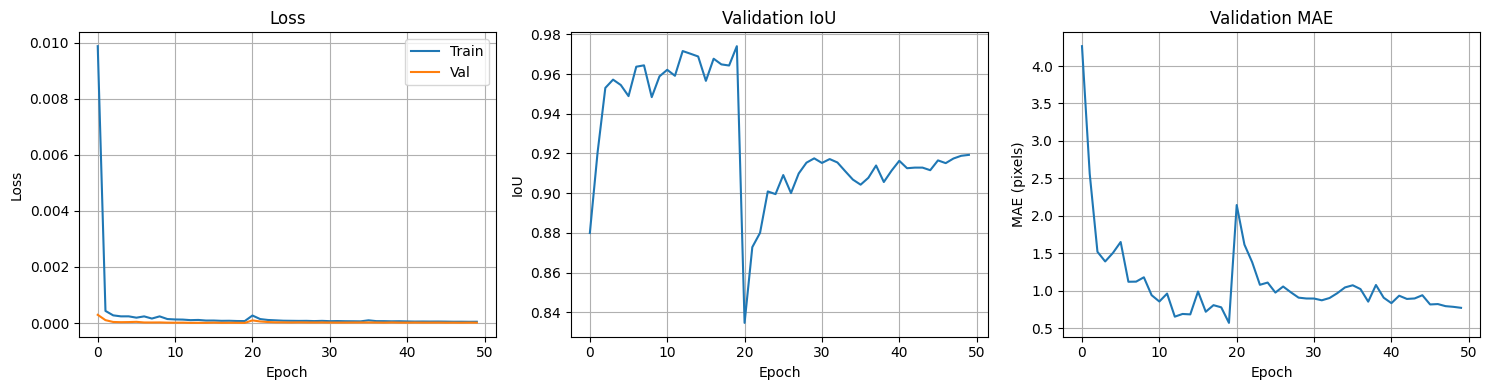

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history['val_iou'])
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].set_title('Validation IoU')
    axes[1].grid(True)

    axes[2].plot(history['val_mae'])
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAE (pixels)')
    axes[2].set_title('Validation MAE')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(trainer.history)

## Visualize Predictions

In [ ]:
def visualize_predictions(model, generator, device, n_samples=6, stage=4):
    model.eval()

    normalize = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))

    for i in range(n_samples):
        img_arr, gt_coords = generator.generate_sample(curriculum_stage=stage)

        img_tensor = normalize(image=img_arr)['image'].unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).cpu().numpy()[0]

        pred_coords = NinePatchCoords.from_array(pred)

        h, w = img_arr.shape[:2]
        gt_px = gt_coords.to_pixels(w, h)
        pred_px = pred_coords.to_pixels(w, h)

        axes[i, 0].imshow(img_arr)
        axes[i, 0].axvline(gt_px.stretch_left, color='green', lw=2, ls='--')
        axes[i, 0].axvline(gt_px.stretch_right, color='green', lw=2)
        axes[i, 0].axhline(gt_px.stretch_top, color='green', lw=2, ls='--')
        axes[i, 0].axhline(gt_px.stretch_bottom, color='green', lw=2)
        axes[i, 0].set_title('Ground Truth')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_arr)
        axes[i, 1].axvline(pred_px.stretch_left, color='red', lw=2, ls='--')
        axes[i, 1].axvline(pred_px.stretch_right, color='red', lw=2)
        axes[i, 1].axhline(pred_px.stretch_top, color='red', lw=2, ls='--')
        axes[i, 1].axhline(pred_px.stretch_bottom, color='red', lw=2)

        iou = compute_region_iou(
            torch.tensor(pred).unsqueeze(0),
            torch.tensor(gt_coords.to_array()).unsqueeze(0)
        ).item()
        axes[i, 1].set_title(f'Prediction (IoU: {iou:.3f})')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

Loaded best model from epoch 20
Val IoU: 0.9741


/tmp/ipython-input-1919646163.py:489: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode='RGBA')


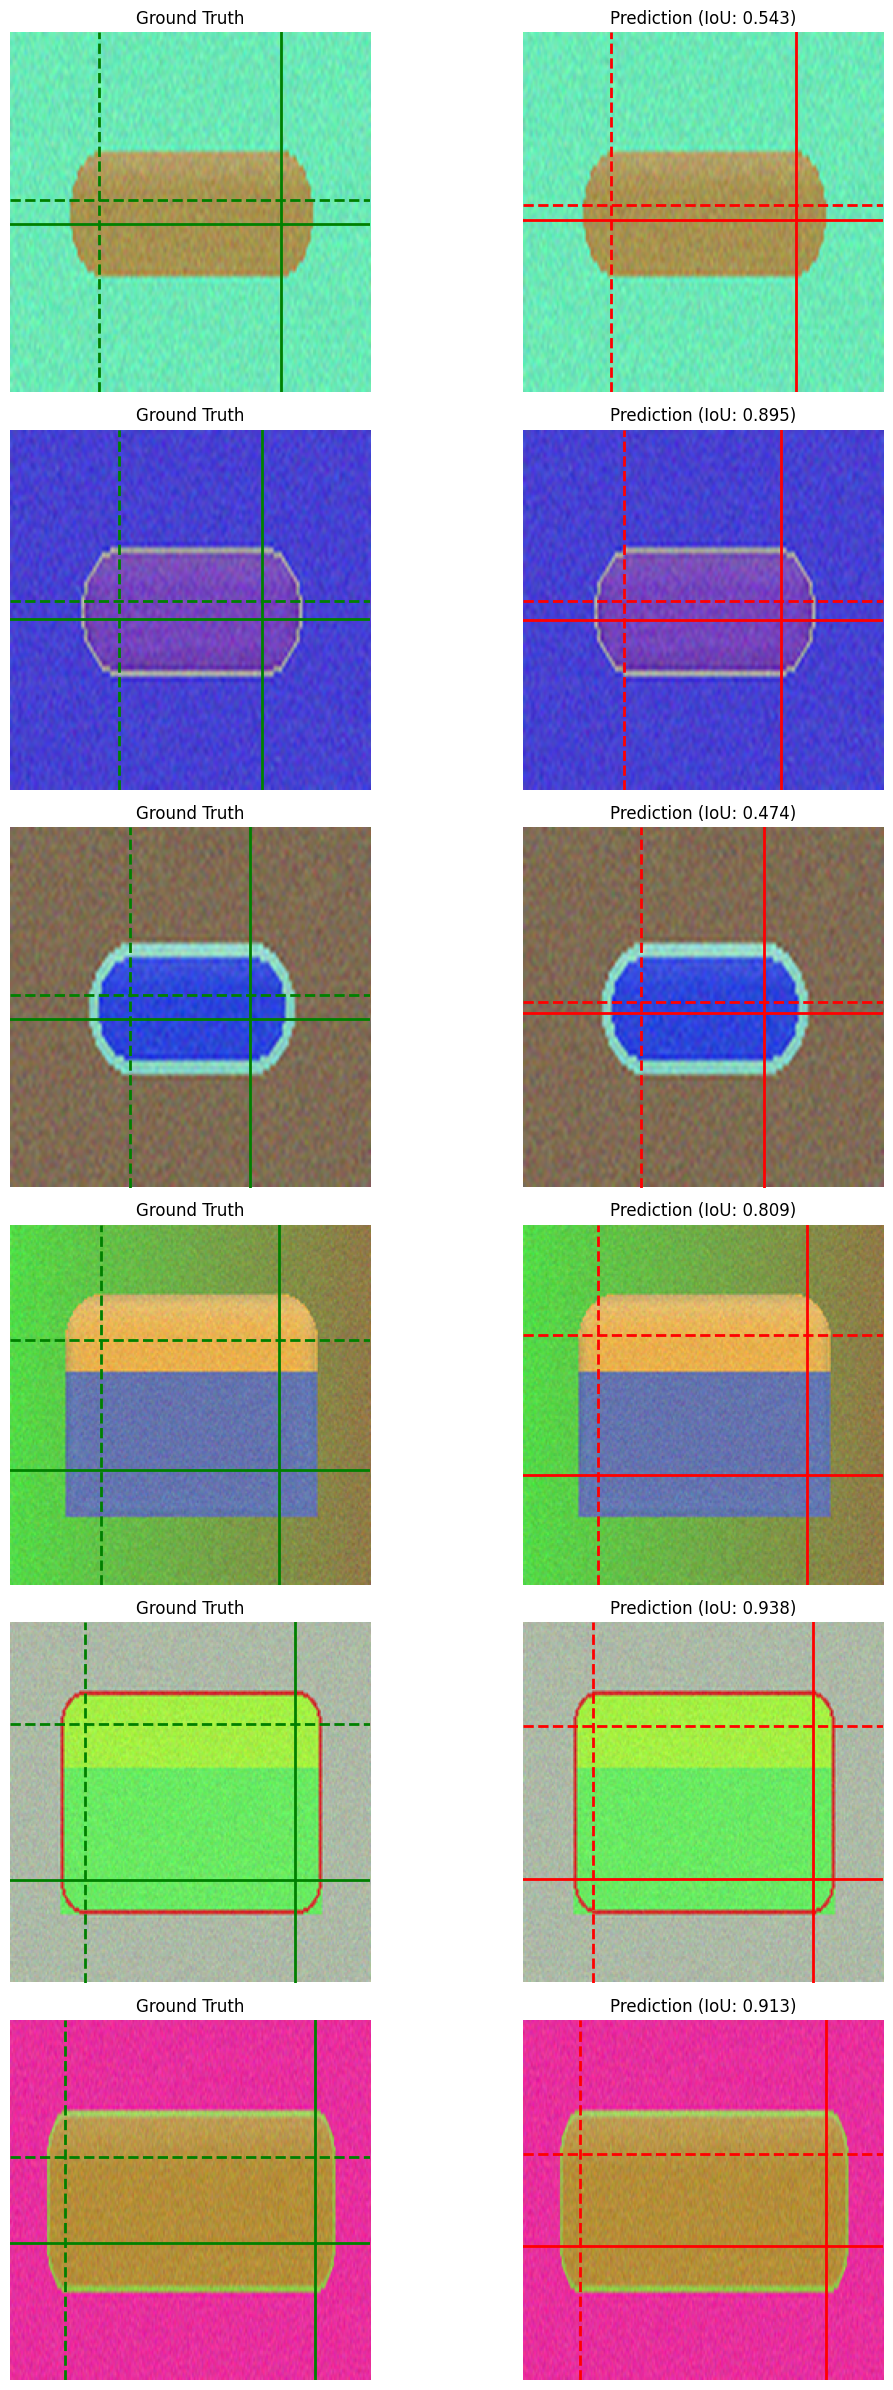

In [ ]:
# Load best model and visualize
best_checkpoint = torch.load(CHECKPOINT_DIR / 'best_model.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(best_checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {best_checkpoint['epoch']}")
print(f"Val IoU: {best_checkpoint['val_metrics']['iou']:.4f}")

visualize_predictions(model, generator, DEVICE, n_samples=6, stage=4)

## Export for Deployment

In [ ]:
# Export to TorchScript
model.eval()
model.cpu()

example_input = torch.randn(1, 3, 224, 224)
traced_model = torch.jit.trace(model, example_input)

export_path = CHECKPOINT_DIR / 'ninepatch_model_v2.pt'
traced_model.save(str(export_path))
print(f"Exported TorchScript model to {export_path}")

# Verify
loaded = torch.jit.load(str(export_path))
test_output = loaded(example_input)
print(f"Verification - output shape: {test_output.shape}")

Exported TorchScript model to /content/drive/MyDrive/9patch_checkpoints_v2/ninepatch_model_v2.pt
Verification - output shape: torch.Size([1, 4])
